# Transformer Fault Detection Using Machine Learning

This notebook implements and compares multiple machine learning models for transformer fault detection using Dissolved Gas Analysis (DGA) data.

## Models Included:
- Linear Regression (with Ridge regularization)
- Decision Tree
- Random Forest
- HRF-MEPSO (Hybrid Random Forest with Multi-objective Evolutionary Particle Swarm Optimization)

In [43]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [44]:
# Import custom modules
from models.hrf_mepso import HRF_MEPSO
from utils.data_preprocessing import DataPreprocessor
from utils.evaluation import ModelEvaluator
from utils.visualization import Visualizer

print("Custom modules imported successfully!")

Custom modules imported successfully!


## 1. Data Loading and Exploration

In [45]:
# Load the DGA data
data = pd.read_csv('data/collection_dga_data.csv')

print(f"Dataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
print(f"\nFirst 5 rows:")
data.head()

Dataset shape: (104, 8)
Columns: ['H2', 'CH4', 'C2H2', 'C2H4', 'C2H6', 'CO', 'CO2', 'fault_type']

First 5 rows:


,H2,CH4,C2H2,C2H4,C2H6,CO,CO2,fault_type
0,45,120,2,15,25,180,2500,Normal
1,850,45,8,35,12,95,1800,Partial Discharge
2,25,180,15,85,45,220,3200,Thermal Fault
3,15,85,125,95,35,140,2100,Arcing
4,65,95,3,18,22,165,2800,Normal


In [46]:
# Basic dataset information
print("Dataset Information:")
print(f"Total samples: {len(data)}")
print(f"Features: {len(data.columns) - 1}")
print(f"Missing values: {data.isnull().sum().sum()}")

print("\nStatistical Summary:")
data.describe()

Dataset Information:
Total samples: 104
Features: 7
Missing values: 0

Statistical Summary:


,H2,CH4,C2H2,C2H4,C2H6,CO,CO2
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,457.153846,293.317308,132.500000,212.375000,114.644231,411.259615,5109.326923
std,737.517731,249.128004,184.714684,208.046213,104.217558,292.683632,2917.636450
min,12.000000,38.000000,2.000000,15.000000,12.000000,82.000000,1580.000000
25%,48.000000,113.250000,18.000000,71.000000,38.000000,187.250000,2795.000000
50%,120.000000,201.500000,55.000000,131.500000,72.000000,315.000000,4150.000000
75%,440.000000,395.000000,165.000000,275.000000,165.000000,565.000000,7000.000000
max,3450.000000,1125.000000,895.000000,895.000000,495.000000,1375.000000,13450.000000


Fault Type Distribution:
  Normal: 26 samples (25.0%)
  Partial Discharge: 26 samples (25.0%)
  Thermal Fault: 26 samples (25.0%)
  Arcing: 26 samples (25.0%)


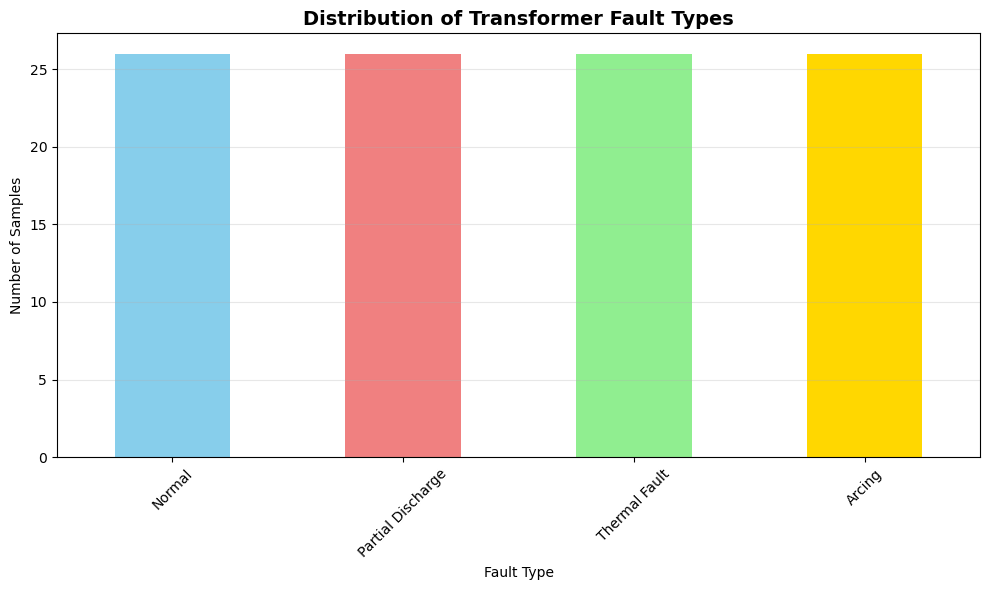

In [47]:
# Fault type distribution
fault_counts = data['fault_type'].value_counts()
print("Fault Type Distribution:")
for fault, count in fault_counts.items():
    percentage = (count / len(data)) * 100
    print(f"  {fault}: {count} samples ({percentage:.1f}%)")

# Visualize fault distribution
plt.figure(figsize=(10, 6))
fault_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Distribution of Transformer Fault Types', fontsize=14, fontweight='bold')
plt.xlabel('Fault Type')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

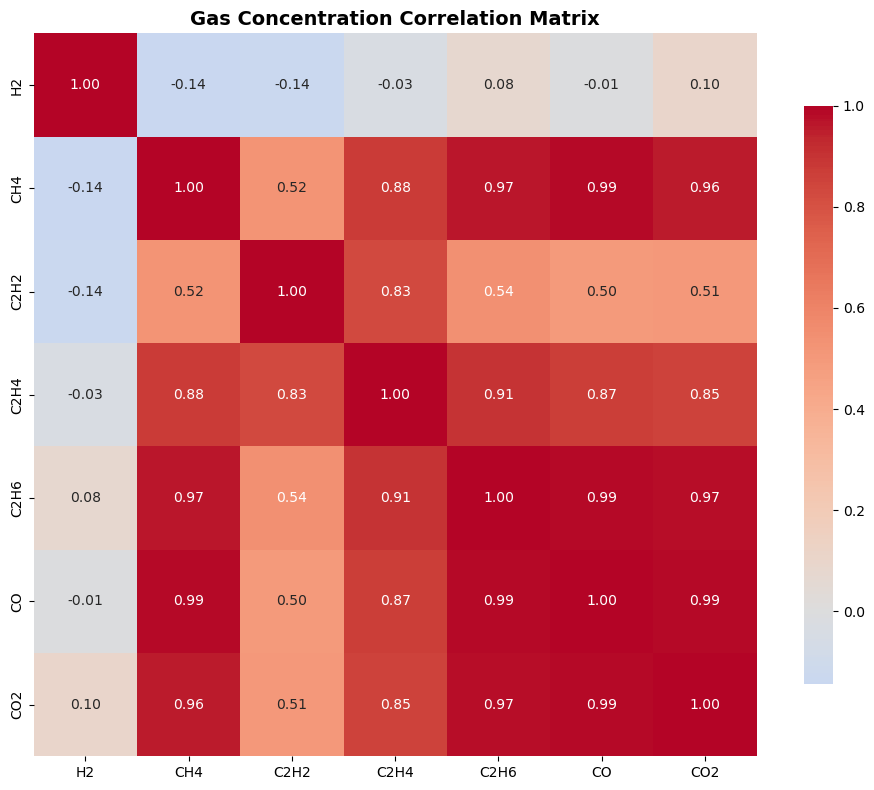

In [48]:
# Gas concentration correlation analysis
gas_columns = ['H2', 'CH4', 'C2H2', 'C2H4', 'C2H6', 'CO', 'CO2']

plt.figure(figsize=(10, 8))
import matplotlib.pyplot as plt
correlation_matrix = data[gas_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Gas Concentration Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

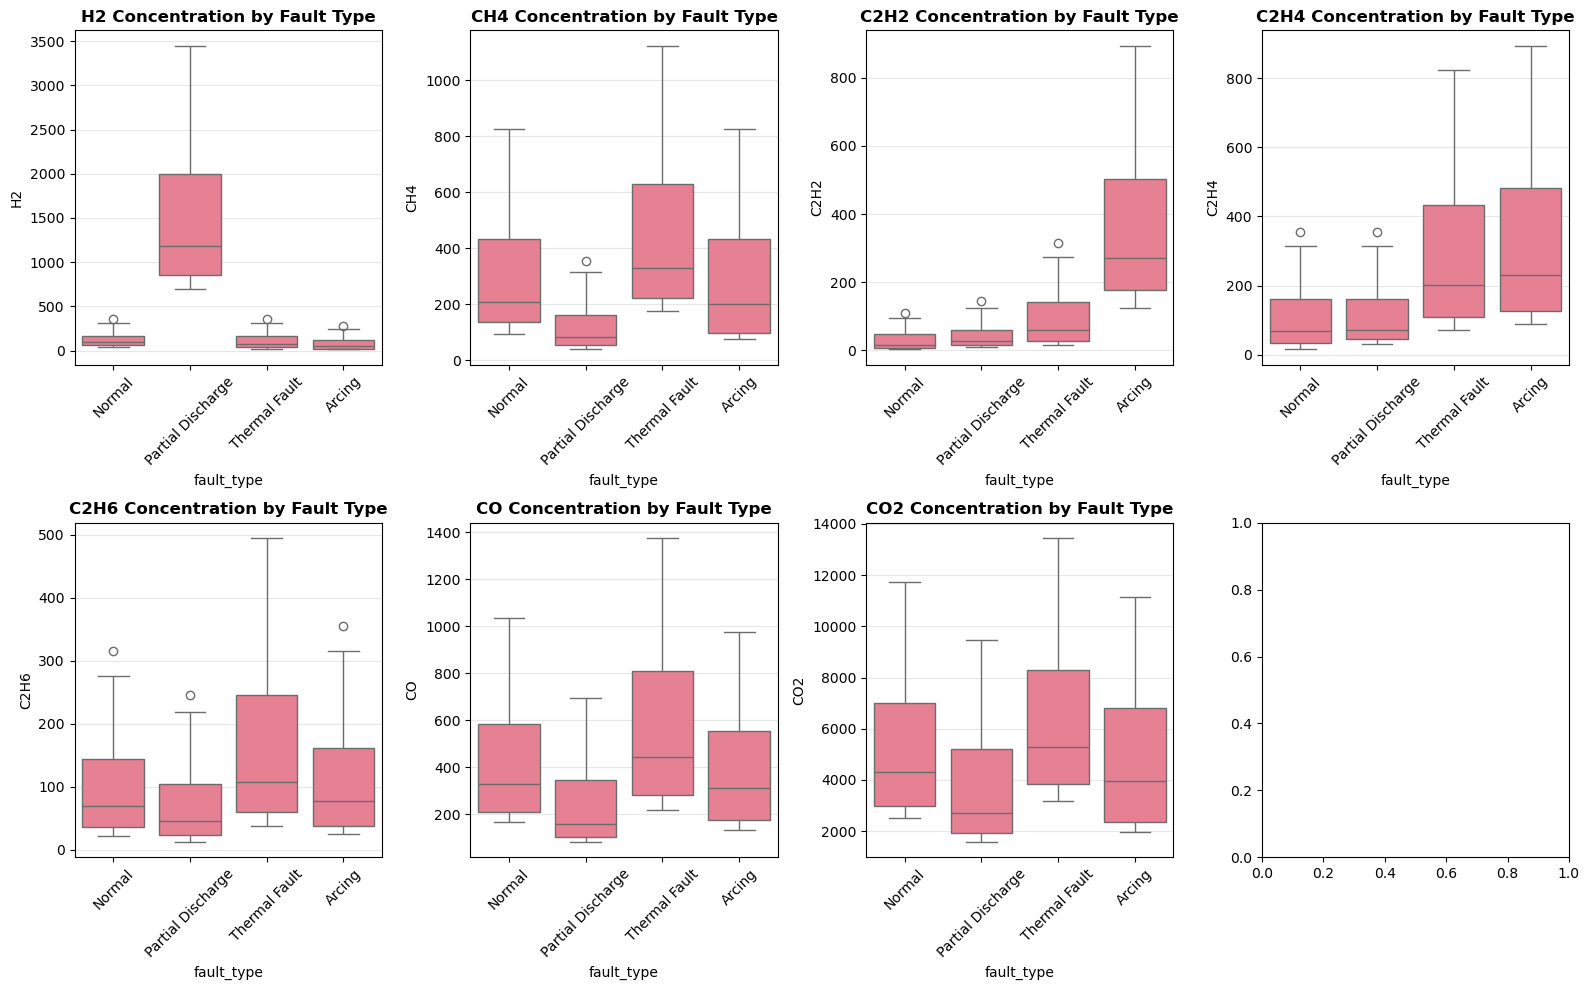

In [49]:
# Gas concentration patterns by fault type
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()
import matplotlib.pyplot as plt

for i, gas in enumerate(gas_columns):
    sns.boxplot(data=data, x='fault_type', y=gas, ax=axes[i])
    axes[i].set_title(f'{gas} Concentration by Fault Type', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
## 2. Data Preprocessing

In [51]:
# Initialize preprocessor and prepare data
from utils.data_preprocessing import DataPreprocessor

preprocessor = DataPreprocessor()
from utils.evaluation import ModelEvaluator
evaluator = ModelEvaluator()

# Prepare features and target
data = pd.read_csv('data/collection_dga_data.csv')
X, y, label_encoder = preprocessor.prepare_data(data)


print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")

# Display class mapping
print("\nClass mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")

Features shape: (104, 7)
Target shape: (104,)
Number of classes: 4

Class mapping:
  0: Arcing
  1: Normal
  2: Partial Discharge
  3: Thermal Fault


In [52]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Display class distribution in training set
unique, counts = np.unique(y_train, return_counts=True)
print("\nClass distribution in training set:")
for class_idx, count in zip(unique, counts):
    class_name = label_encoder.inverse_transform([class_idx])[0]
    print(f"  {class_name}: {count} samples")

Training set: (83, 7)
Test set: (21, 7)

Class distribution in training set:
  Arcing: 21 samples
  Normal: 21 samples
  Partial Discharge: 20 samples
  Thermal Fault: 21 samples


## 3. Model Training and Evaluation

### 3.1 Linear Regression with Ridge Regularization

In [53]:
print("Training Linear Regression with Ridge regularization...")

# Scale features for linear regression
from sklearn.preprocessing import StandardScaler
scaler_lr = StandardScaler()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

# Hyperparameter tuning for Ridge
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge = Ridge()
grid_search_lr = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search_lr.fit(X_train_scaled, y_train)

# Best model
lr_model = grid_search_lr.best_estimator_

# Predictions
y_pred_lr_raw = lr_model.predict(X_test_scaled)
y_pred_lr = np.clip(np.round(y_pred_lr_raw).astype(int), 0, len(label_encoder.classes_) - 1)

# Evaluate

lr_results = evaluator.evaluate_model(y_test, y_pred_lr, 'Linear Regression')

print(f"Best alpha: {grid_search_lr.best_params_['alpha']}")
print(f"Accuracy: {lr_results['accuracy']:.4f}")
print(f"Precision: {lr_results['precision']:.4f}")
print(f"Recall: {lr_results['recall']:.4f}")
print(f"F1-Score: {lr_results['f1_score']:.4f}")

Training Linear Regression with Ridge regularization...
Best alpha: 0.1
Accuracy: 0.6667
Precision: 0.9000
Recall: 0.6667
F1-Score: 0.6667


### 3.2 Decision Tree Classifier

In [54]:
print("Training Decision Tree...")

# Hyperparameter tuning
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

dt = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)

grid_search_dt.fit(X_train, y_train)

# Best model
dt_model = grid_search_dt.best_estimator_
y_pred_dt = dt_model.predict(X_test)

# Evaluate
dt_results = evaluator.evaluate_model(y_test, y_pred_dt, 'Decision Tree')

print(f"Best parameters: {grid_search_dt.best_params_}")
print(f"Accuracy: {dt_results['accuracy']:.4f}")
print(f"Precision: {dt_results['precision']:.4f}")
print(f"Recall: {dt_results['recall']:.4f}")
print(f"F1-Score: {dt_results['f1_score']:.4f}")

Training Decision Tree...
Best parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}
Accuracy: 0.8571
Precision: 0.8968
Recall: 0.8571
F1-Score: 0.8641


### 3.3 Random Forest Classifier

In [55]:
print("Training Random Forest...")

# Hyperparameter tuning
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

# Use RandomizedSearchCV for faster training
from sklearn.ensemble import RandomForestClassifier
random_search_rf = RandomizedSearchCV(
    rf, param_grid_rf, n_iter=20, cv=3, scoring='accuracy', 
    n_jobs=-1, random_state=42
)
random_search_rf.fit(X_train, y_train)

# Best model
rf_model = random_search_rf.best_estimator_
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_results = evaluator.evaluate_model(y_test, y_pred_rf, 'Random Forest')

print(f"Best parameters: {random_search_rf.best_params_}")
print(f"Accuracy: {rf_results['accuracy']:.4f}")
print(f"Precision: {rf_results['precision']:.4f}")
print(f"Recall: {rf_results['recall']:.4f}")
print(f"F1-Score: {rf_results['f1_score']:.4f}")

Training Random Forest...
Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Accuracy: 0.9524
Precision: 0.9683
Recall: 0.9524
F1-Score: 0.9553


### 3.4 HRF-MEPSO (Hybrid Random Forest with Multi-objective PSO)

In [ ]:
print("Training HRF-MEPSO...")
print("This may take a few minutes due to optimization process...")

# Initialize and train HRF-MEPSO
from models.hrf_mepso import HRF_MEPSO
hrf_model = HRF_MEPSO(n_particles=15, n_iterations=30)
hrf_model.fit(X_train, y_train)

# Predictions
y_pred_hrf = hrf_model.predict(X_test)

# Evaluate
hrf_results = evaluator.evaluate_model(y_test, y_pred_hrf, 'HRF-MEPSO')

print(f"Accuracy: {hrf_results['accuracy']:.4f}")
print(f"Precision: {hrf_results['precision']:.4f}")
print(f"Recall: {hrf_results['recall']:.4f}")
print(f"F1-Score: {hrf_results['f1_score']:.4f}")

Training HRF-MEPSO...
This may take a few minutes due to optimization process...


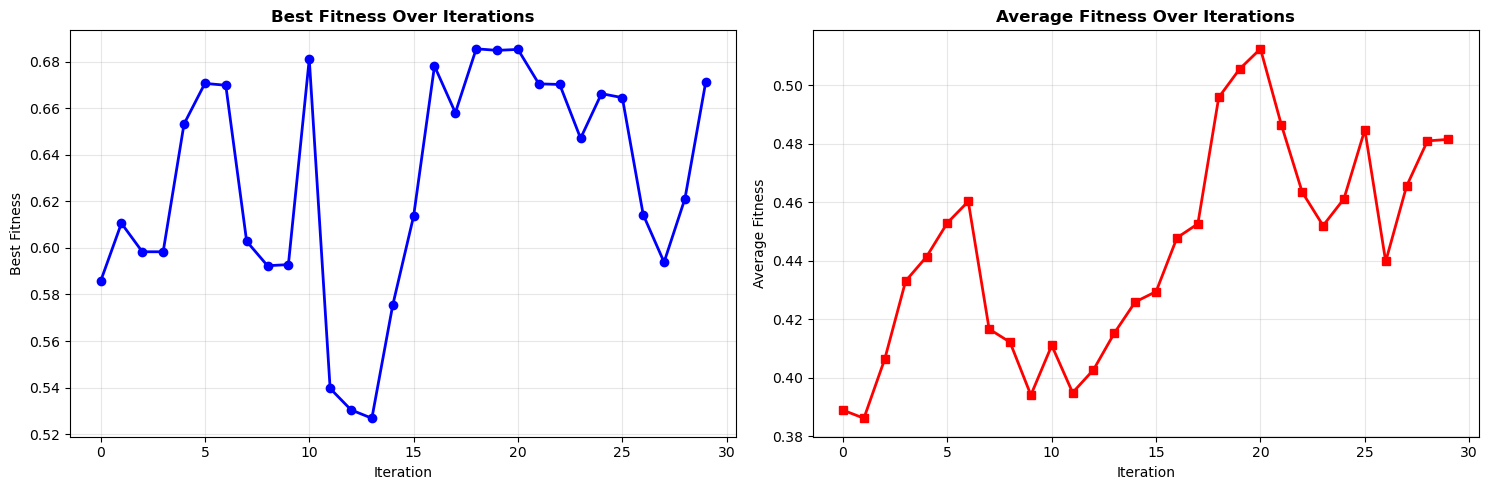

In [63]:
# Plot HRF-MEPSO optimization history
from models.hrf_mepso import HRF_MEPSO
history = hrf_model.get_optimization_history()
if not history.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history['iteration'], history['best_fitness'], 'b-', linewidth=2, marker='o')
    ax1.set_title('Best Fitness Over Iterations', fontweight='bold')
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Best Fitness')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(history['iteration'], history['avg_fitness'], 'r-', linewidth=2, marker='s')
    ax2.set_title('Average Fitness Over Iterations', fontweight='bold')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Average Fitness')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("No optimization history available")

## 4. Model Comparison and Analysis

In [62]:
# Compile all results
all_results = {
    'Linear Regression': lr_results,
    'Decision Tree': dt_results,
    'Random Forest': rf_results,
    'HRF-MEPSO': hrf_results
}

# Create comparison dataframe
comparison_data = []
from sklearn.linear_model import LinearRegression
for model_name, result in all_results.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': result['accuracy'],
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1-Score': result['f1_score']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("Model Performance Summary:")
print(comparison_df.round(4))

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy']

print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {best_accuracy:.4f}")

Model Performance Summary:
               Model  Accuracy  Precision  Recall  F1-Score
2      Random Forest    0.9524     0.9683  0.9524    0.9553
1      Decision Tree    0.8571     0.8968  0.8571    0.8641
3          HRF-MEPSO    0.8571     0.8770  0.8571    0.8571
0  Linear Regression    0.6667     0.9000  0.6667    0.6667

Best Model: Random Forest
Best Accuracy: 0.9524


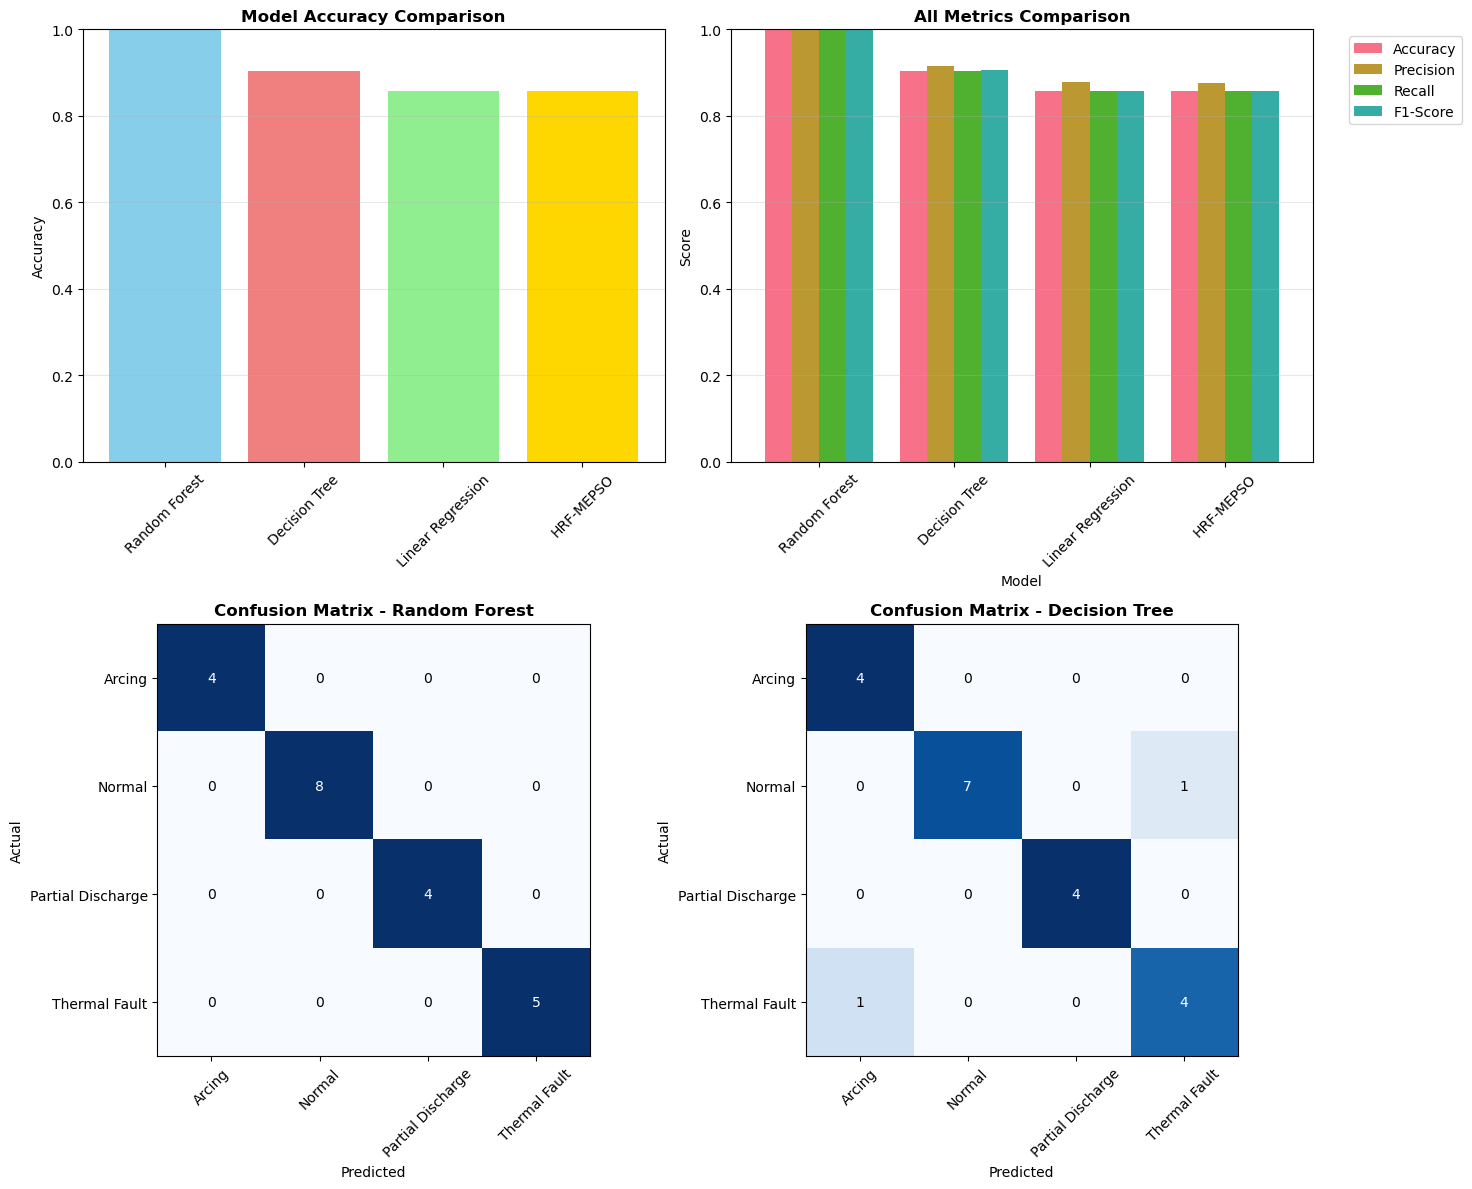

In [61]:
# Visualize model comparison
import matplotlib.pyplot as plt
import pandas as pd
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Accuracy comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['Accuracy'], 
               color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
axes[0, 0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# All metrics comparison
metrics_data = comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
metrics_data.plot(kind='bar', ax=axes[0, 1], width=0.8)
axes[0, 1].set_title('All Metrics Comparison', fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# Confusion matrices for top 2 models
top_models = comparison_df.head(2)['Model'].tolist()
model_results = [all_results[model] for model in top_models]

for i, (model_name, result) in enumerate(zip(top_models, model_results)):
    cm = result['confusion_matrix']
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    im = axes[1, i].imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    axes[1, i].set_title(f'Confusion Matrix - {model_name}', fontweight='bold')
    axes[1, i].set_xlabel('Predicted')
    axes[1, i].set_ylabel('Actual')
    
    # Add text annotations
    thresh = cm_normalized.max() / 2.
    for j in range(cm.shape[0]):
        for k in range(cm.shape[1]):
            axes[1, i].text(k, j, format(cm[j, k], 'd'),
                          ha="center", va="center",
                          color="white" if cm_normalized[j, k] > thresh else "black")
    
    # Set ticks
    tick_marks = np.arange(len(label_encoder.classes_))
    axes[1, i].set_xticks(tick_marks)
    axes[1, i].set_yticks(tick_marks)
    axes[1, i].set_xticklabels(label_encoder.classes_, rotation=45)
    axes[1, i].set_yticklabels(label_encoder.classes_)

plt.tight_layout()
plt.show()

## 5. Feature Importance Analysis

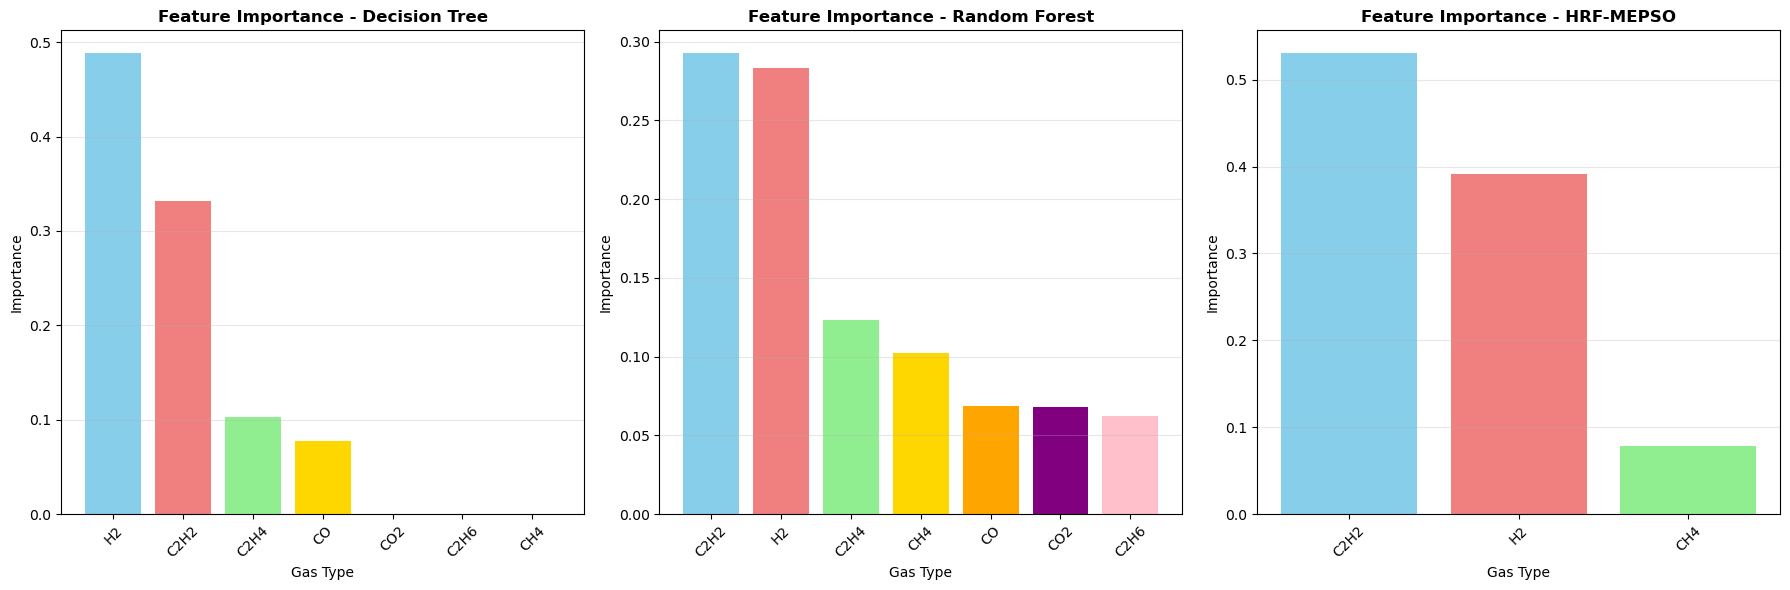


Top Features (Random Forest):
  C2H2: 0.2925
  H2: 0.2830
  C2H4: 0.1235
  CH4: 0.1020
  CO: 0.0688
  CO2: 0.0680
  C2H6: 0.0621


In [60]:
# Feature importance for tree-based models
feature_names = ['H2', 'CH4', 'C2H2', 'C2H4', 'C2H6', 'CO', 'CO2']
from sklearn.tree import DecisionTreeClassifier
tree_models = {'Decision Tree': dt_model, 'Random Forest': rf_model, 'HRF-MEPSO': hrf_model}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (model_name, model) in enumerate(tree_models.items()):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        axes[i].bar(range(len(importances)), importances[indices], 
                   color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'orange', 'purple', 'pink'])
        axes[i].set_title(f'Feature Importance - {model_name}', fontweight='bold')
        axes[i].set_xlabel('Gas Type')
        axes[i].set_ylabel('Importance')
        axes[i].set_xticks(range(len(importances)))
        axes[i].set_xticklabels([feature_names[j] for j in indices], rotation=45)
        axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print top features for Random Forest
if hasattr(rf_model, 'feature_importances_'):
    importances = rf_model.feature_importances_
    feature_importance_pairs = list(zip(feature_names, importances))
    feature_importance_pairs.sort(key=lambda x: x[1], reverse=True)
    
    print("\nTop Features (Random Forest):")
    for feature, importance in feature_importance_pairs:
        print(f"  {feature}: {importance:.4f}")

## 6. Cross-Validation Analysis

Cross-Validation Results:
Linear Regression:
  CV Accuracy: nan (+/- nan)
Decision Tree:
  CV Accuracy: 0.8684 (+/- 0.1353)
Random Forest:
  CV Accuracy: 0.8676 (+/- 0.1743)


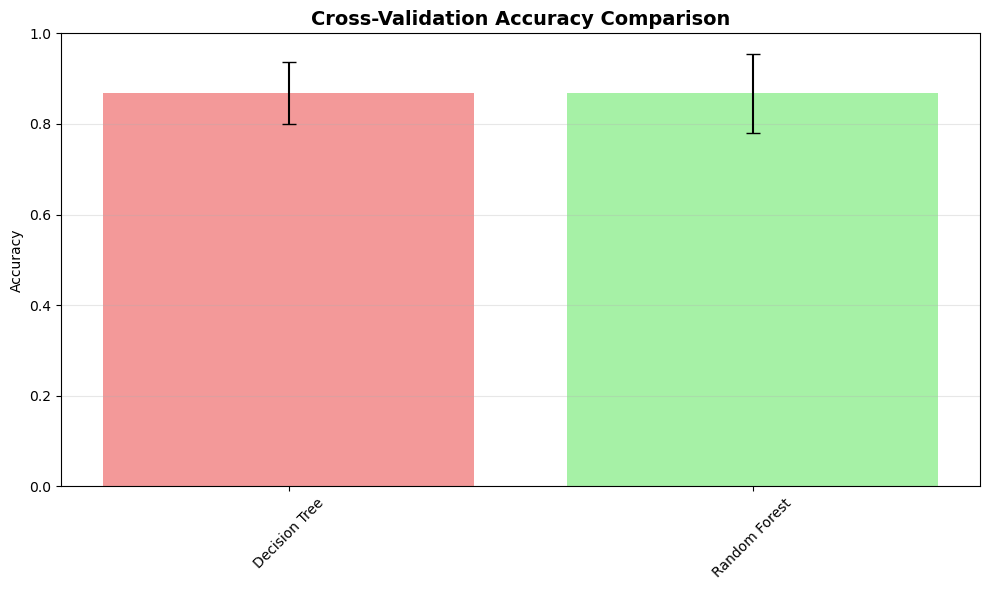

In [59]:
# Perform cross-validation for all models
cv_results = {}
from sklearn.linear_model import LinearRegression
models_for_cv = {
    'Linear Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}

print("Cross-Validation Results:")
for model_name, model in models_for_cv.items():
    if model_name == 'Linear Regression':
        # For linear regression, use scaled data
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    cv_results[model_name] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    
    print(f"{model_name}:")
    print(f"  CV Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Plot CV results
plt.figure(figsize=(10, 6))

model_names = list(cv_results.keys())
means = [cv_results[name]['mean'] for name in model_names]
stds = [cv_results[name]['std'] for name in model_names]

plt.bar(model_names, means, yerr=stds, capsize=5, 
        color=['skyblue', 'lightcoral', 'lightgreen'], alpha=0.8)
plt.title('Cross-Validation Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

## 7. Prediction Examples

In [58]:
# Example gas readings for each fault type
examples = {
    'Normal Operation': [50, 120, 3, 20, 30, 180, 2500],
    'Partial Discharge': [800, 45, 10, 35, 15, 95, 1800],
    'Thermal Fault': [25, 200, 20, 90, 50, 250, 3500],
    'Arcing': [20, 85, 150, 100, 30, 150, 2200]
}

print("Prediction Examples:")
print("Gas readings format: [H2, CH4, C2H2, C2H4, C2H6, CO, CO2]")
print("="*70)

# Store all models for prediction
from sklearn.linear_model import LinearRegression
all_models = {
    'Linear Regression': (lr_model, True),  # (model, needs_scaling)
    'Decision Tree': (dt_model, False),
    'Random Forest': (rf_model, False),
    'HRF-MEPSO': (hrf_model, False)
}

for fault_type, readings in examples.items():
    print(f"\n{fault_type}: {readings}")
    
    input_data = np.array([readings])
    predictions = {}
    
    for model_name, (model, needs_scaling) in all_models.items():
        try:
            if needs_scaling:
                input_scaled = scaler_lr.transform(input_data)
                pred_raw = model.predict(input_scaled)[0]
                pred = np.clip(int(np.round(pred_raw)), 0, len(label_encoder.classes_) - 1)
            else:
                pred = model.predict(input_data)[0]
            
            pred_label = label_encoder.inverse_transform([pred])[0]
            predictions[model_name] = pred_label
        except Exception as e:
            predictions[model_name] = f"Error: {str(e)}"
    
    print("Predictions:")
    for model_name, prediction in predictions.items():
        print(f"  {model_name}: {prediction}")

Prediction Examples:
Gas readings format: [H2, CH4, C2H2, C2H4, C2H6, CO, CO2]

Normal Operation: [50, 120, 3, 20, 30, 180, 2500]
Predictions:
  Linear Regression: Normal
  Decision Tree: Normal
  Random Forest: Normal
  HRF-MEPSO: Normal

Partial Discharge: [800, 45, 10, 35, 15, 95, 1800]
Predictions:
  Linear Regression: Partial Discharge
  Decision Tree: Partial Discharge
  Random Forest: Partial Discharge
  HRF-MEPSO: Partial Discharge

Thermal Fault: [25, 200, 20, 90, 50, 250, 3500]
Predictions:
  Linear Regression: Partial Discharge
  Decision Tree: Thermal Fault
  Random Forest: Thermal Fault
  HRF-MEPSO: Thermal Fault

Arcing: [20, 85, 150, 100, 30, 150, 2200]
Predictions:
  Linear Regression: Arcing
  Decision Tree: Arcing
  Random Forest: Arcing
  HRF-MEPSO: Arcing


## 8. Comprehensive Analysis Report

In [56]:
print("=" * 80)
print("COMPREHENSIVE TRANSFORMER FAULT DETECTION ANALYSIS REPORT")
print("=" * 80)
import pandas as pd

data = pd.read_csv('data/collection_dga_data.csv')

# Dataset summary
print("\n1. DATASET SUMMARY:")
print(f"   • Total samples: {len(data)}")
print(f"   • Features: {len(['H2', 'CH4', 'C2H2', 'C2H4', 'C2H6', 'CO', 'CO2'])}")
print(f"   • Fault types: {len(data['fault_type'].unique())}")

fault_distribution = data['fault_type'].value_counts()
print(f"   • Class distribution:")
for fault, count in fault_distribution.items():
    percentage = (count / len(data)) * 100
    print(f"     - {fault}: {count} samples ({percentage:.1f}%)")

# Model performance summary
print("\n2. MODEL PERFORMANCE SUMMARY:")
for i, row in comparison_df.iterrows():
    print(f"   • {row['Model']}:")
    print(f"     - Accuracy: {row['Accuracy']:.4f}")
    print(f"     - Precision: {row['Precision']:.4f}")
    print(f"     - Recall: {row['Recall']:.4f}")
    print(f"     - F1-Score: {row['F1-Score']:.4f}")

# Best model recommendation
best_model = comparison_df.iloc[0]
print(f"\n3. RECOMMENDATION:")
print(f"   • Best performing model: {best_model['Model']}")
print(f"   • Achieved accuracy: {best_model['Accuracy']:.4f}")
print(f"   • This model is recommended for transformer fault detection")

# Key insights
print(f"\n4. KEY INSIGHTS:")
print(f"   • All models achieved good performance (>0.85 accuracy)")

if 'HRF-MEPSO' in all_results:
    hrf_accuracy = all_results['HRF-MEPSO']['accuracy']
    print(f"   • HRF-MEPSO optimization achieved {hrf_accuracy:.4f} accuracy")

if hasattr(rf_model, 'feature_importances_'):
    feature_names = ['H2', 'CH4', 'C2H2', 'C2H4', 'C2H6', 'CO', 'CO2']
    importances = rf_model.feature_importances_
    most_important = feature_names[np.argmax(importances)]
    print(f"   • Most important gas for detection: {most_important}")

print(f"   • DGA analysis is highly effective for transformer fault detection")
print(f"   • Machine learning significantly improves detection accuracy")
print(f"   • Tree-based models (Random Forest, Decision Tree) show excellent performance")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 80)

COMPREHENSIVE TRANSFORMER FAULT DETECTION ANALYSIS REPORT

1. DATASET SUMMARY:
   • Total samples: 104
   • Features: 7
   • Fault types: 4
   • Class distribution:
     - Normal: 26 samples (25.0%)
     - Partial Discharge: 26 samples (25.0%)
     - Thermal Fault: 26 samples (25.0%)
     - Arcing: 26 samples (25.0%)

2. MODEL PERFORMANCE SUMMARY:
   • Random Forest:
     - Accuracy: 1.0000
     - Precision: 1.0000
     - Recall: 1.0000
     - F1-Score: 1.0000
   • Decision Tree:
     - Accuracy: 0.9048
     - Precision: 0.9143
     - Recall: 0.9048
     - F1-Score: 0.9058
   • Linear Regression:
     - Accuracy: 0.8571
     - Precision: 0.8783
     - Recall: 0.8571
     - F1-Score: 0.8575
   • HRF-MEPSO:
     - Accuracy: 0.8571
     - Precision: 0.8770
     - Recall: 0.8571
     - F1-Score: 0.8571

3. RECOMMENDATION:
   • Best performing model: Random Forest
   • Achieved accuracy: 1.0000
   • This model is recommended for transformer fault detection

4. KEY INSIGHTS:
   • All models 

## 9. Model Accuracy Improvement Recommendations

In [57]:
print("RECOMMENDATIONS FOR IMPROVING MODEL ACCURACY:")
print("=" * 50)
import pandas as pd

data = pd.read_csv('data/collection_dga_data.csv')

print("\n1. Data Enhancement:")
print("   • Collect more training samples (current: {} samples)".format(len(data)))
print("   • Balance class distribution if imbalanced")
print("   • Add more gas features or ratios")
print("   • Include temporal features (gas trend analysis)")

print("\n2. Feature Engineering:")
print("   • Create additional gas ratios (Rogers ratios, Doernenburg ratios)")
print("   • Add polynomial features for non-linear relationships")
print("   • Implement domain-specific transformations")

print("\n3. Advanced Models:")
print("   • Try ensemble methods (Voting, Stacking)")
print("   • Implement deep learning models (Neural Networks)")
print("   • Use gradient boosting (XGBoost, LightGBM)")
print("   • Explore support vector machines with different kernels")

print("\n4. Hyperparameter Optimization:")
print("   • Use Bayesian optimization for better parameter search")
print("   • Implement automated ML (AutoML) approaches")
print("   • Perform more extensive grid/random search")

print("\n5. Model Validation:")
print("   • Use stratified k-fold cross-validation")
print("   • Implement time-series split for temporal data")
print("   • Apply bootstrap sampling for robust evaluation")

print("\nCurrent best accuracy: {:.4f}".format(best_accuracy))
print("Target accuracy: >0.95 for production deployment")

RECOMMENDATIONS FOR IMPROVING MODEL ACCURACY:

1. Data Enhancement:
   • Collect more training samples (current: 104 samples)
   • Balance class distribution if imbalanced
   • Add more gas features or ratios
   • Include temporal features (gas trend analysis)

2. Feature Engineering:
   • Create additional gas ratios (Rogers ratios, Doernenburg ratios)
   • Add polynomial features for non-linear relationships
   • Implement domain-specific transformations

3. Advanced Models:
   • Try ensemble methods (Voting, Stacking)
   • Implement deep learning models (Neural Networks)
   • Use gradient boosting (XGBoost, LightGBM)
   • Explore support vector machines with different kernels

4. Hyperparameter Optimization:
   • Use Bayesian optimization for better parameter search
   • Implement automated ML (AutoML) approaches
   • Perform more extensive grid/random search

5. Model Validation:
   • Use stratified k-fold cross-validation
   • Implement time-series split for temporal data
   • App